In [1]:
import pandas as pd

customers = pd.read_csv("customers.csv")
customers.head()

,customer_id,country,age,gender,membership_tier,registration_date,total_orders,total_spend_usd,avg_order_value_usd,days_since_last_purchase,preferred_category,preferred_device,preferred_payment_method,acquisition_channel,reviews_given,avg_review_score,returns_made,wishlist_items,newsletter_subscribed,churned
0,C00001,United States,40,Male,Free,2019-01-17,4,286.63,63.78,49,Food & Grocery,Mobile,Debit Card,Social Media,1,4.5,0,12,0,0
1,C00002,United States,20,Female,Free,2026-03-04,11,1245.18,107.32,126,Toys & Games,Mobile,Debit Card,Organic Search,2,2.6,1,1,0,0
2,C00003,United States,43,Female,Gold,2026-02-08,4,195.37,42.74,0,Home & Kitchen,Mobile,PayPal,Referral,0,4.8,0,0,1,0
3,C00004,United States,41,Male,Free,2025-03-19,6,99.45,15.61,6,Electronics,Desktop,PayPal,Organic Search,2,4.2,0,8,1,0
4,C00005,France,37,Other,Platinum,2024-09-10,36,2593.21,79.09,161,Clothing & Apparel,Tablet,Debit Card,Social Media,9,4.0,4,5,1,0


In [2]:
orders = pd.read_csv("orders.csv")
orders.head()

,order_id,customer_id,order_date,year,month,quarter,day_of_week,product_name,category,unit_price_usd,...,payment_method,device_used,delivery_days,delivery_date,order_status,returned,customer_rating,session_duration_minutes,pages_viewed_before_purchase,is_repeat_customer
0,O000001,C07108,2020-08-27,2020,8,Q3,Thursday,Tire Inflator,Automotive,62.91,...,Credit Card,Desktop,3,2020-08-30,Delivered,0,NaN,14.4,1,1
1,O000002,C03487,2024-04-11,2024,4,Q2,Thursday,Stud Earrings Gold,Jewelry & Accessories,18.44,...,Credit Card,Mobile,2,2024-04-13,Delivered,0,NaN,9.0,4,0
2,O000003,C03062,2023-06-25,2023,6,Q2,Sunday,Pen Set Premium,Office Supplies,109.79,...,PayPal,Desktop,3,2023-06-28,Delivered,0,4.0,3.2,17,0
3,O000004,C00888,2020-08-16,2020,8,Q3,Sunday,Smart Watch Series 5,Electronics,87.21,...,Credit Card,Tablet,2,2020-08-18,Returned,1,NaN,32.2,3,1
4,O000005,C01674,2020-04-24,2020,4,Q2,Friday,Stud Earrings Gold,Jewelry & Accessories,94.30,...,Debit Card,Mobile,5,2020-04-29,Delivered,0,2.8,54.7,2,1


In [3]:
# total spend per customer
total_spend = orders.groupby("customer_id")["total_amount_usd"].sum()

# total number of orders
total_orders = orders.groupby("customer_id")["order_id"].count()

# average order value
avg_order_value = total_spend / total_orders

In [4]:
customers = customers.merge(total_spend, on="customer_id", how="left")
customers = customers.merge(total_orders, on="customer_id", how="left")

customers["avg_order_value"] = customers["total_amount_usd"] / customers["order_id"]

In [6]:
customers.fillna(0, inplace=True)
customers = pd.get_dummies(customers, drop_first=True)

In [11]:
customers.columns

Index(['age', 'total_orders', 'total_spend_usd', 'avg_order_value_usd',
       'days_since_last_purchase', 'reviews_given', 'avg_review_score',
       'returns_made', 'wishlist_items', 'newsletter_subscribed',
       ...
       'preferred_payment_method_Credit Card',
       'preferred_payment_method_Cryptocurrency',
       'preferred_payment_method_Debit Card',
       'preferred_payment_method_PayPal',
       'preferred_payment_method_UPI / Digital Wallet',
       'acquisition_channel_Email Campaign',
       'acquisition_channel_Organic Search', 'acquisition_channel_Paid Ad',
       'acquisition_channel_Referral', 'acquisition_channel_Social Media'],
      dtype='object', length=9924)

In [12]:
"churned" in customers.columns

True

In [13]:
X = customers.drop("churned", axis=1)
y = customers["churned"]

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [15]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

model.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [16]:
preds = model.predict(X_test)

In [17]:
from sklearn.metrics import classification_report

print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       0.89      1.00      0.94      1431
           1       0.00      0.00      0.00       169

    accuracy                           0.89      1600
   macro avg       0.45      0.50      0.47      1600
weighted avg       0.80      0.89      0.84      1600



c:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [18]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    class_weight="balanced"
)

model.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [24]:
preds = model.predict(X_test)

from sklearn.metrics import classification_report
print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       0.94      0.85      0.89      1431
           1       0.30      0.54      0.39       169

    accuracy                           0.82      1600
   macro avg       0.62      0.70      0.64      1600
weighted avg       0.87      0.82      0.84      1600



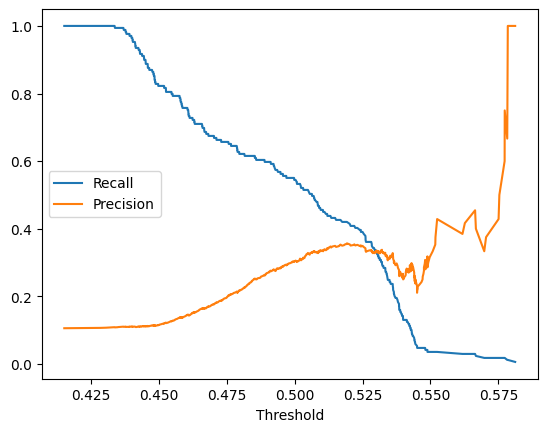

In [25]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(y_test, probs)

plt.plot(thresholds, recall[:-1], label="Recall")
plt.plot(thresholds, precision[:-1], label="Precision")
plt.xlabel("Threshold")
plt.legend()
plt.show()

In [28]:
import numpy as np
np.unique(custom_preds, return_counts=True)

(array([1]), array([1600]))

In [29]:
custom_preds = (probs > 0.45).astype(int)

In [30]:
np.unique(custom_preds, return_counts=True)

(array([0, 1]), array([ 393, 1207]))

In [31]:
for t in [0.45, 0.5, 0.55, 0.6]:
    preds = (probs > t).astype(int)
    counts = np.unique(preds, return_counts=True)
    print(f"Threshold {t} → {counts}")

Threshold 0.45 → (array([0, 1]), array([ 393, 1207]))
Threshold 0.5 → (array([0, 1]), array([1297,  303]))
Threshold 0.55 → (array([0, 1]), array([1582,   18]))
Threshold 0.6 → (array([0]), array([1600]))


In [32]:
final_preds = (probs > 0.5).astype(int)

In [33]:
from sklearn.metrics import classification_report

print(classification_report(y_test, final_preds))

              precision    recall  f1-score   support

           0       0.94      0.85      0.89      1431
           1       0.30      0.54      0.39       169

    accuracy                           0.82      1600
   macro avg       0.62      0.70      0.64      1600
weighted avg       0.87      0.82      0.84      1600



In [34]:
import pickle

pickle.dump(model, open("churn_model.pkl", "wb"))
pickle.dump(X.columns, open("model_columns.pkl", "wb"))